In [1]:
from pathlib import Path
import heapq

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [2]:
DATA_PATH = Path("../data/processed/asset_failure_risks.csv")

assets = pd.read_csv(DATA_PATH)

print("Number of assets:", len(assets))
assets

Number of assets: 10


,Asset ID,Source Row,Failure Risk,Risk Level
0,M01,1391,0.940000,CRITICAL
1,M02,2444,0.853333,CRITICAL
2,M03,5706,0.760000,HIGH
3,M04,8846,0.656667,HIGH
4,M05,5701,0.550000,MEDIUM
5,M06,4283,0.450000,MEDIUM
6,M07,4028,0.353333,LOW
7,M08,4466,0.246667,LOW
8,M09,2856,0.146667,LOW
9,M10,9482,0.050000,LOW


In [3]:
factory_positions = {
    "M01": (3, 2),
    "M02": (7, 2),
    "M03": (11, 2),
    "M04": (4, 5),
    "M05": (9, 5),
    "M06": (14, 5),
    "M07": (2, 8),
    "M08": (7, 8),
    "M09": (12, 8),
    "M10": (17, 8),
}

TECHNICIAN_START = (1, 5)

missing_positions = (
    set(assets["Asset ID"])
    - set(factory_positions)
)

if missing_positions:
    raise ValueError(
        f"Missing factory positions: {missing_positions}"
    )

print("Technician start:", TECHNICIAN_START)

Technician start: (1, 5)


In [4]:
rng = np.random.default_rng(42)

assets["Criticality"] = rng.uniform(
    0.4,
    1.0,
    len(assets)
)

assets["Urgency"] = rng.uniform(
    0.4,
    1.0,
    len(assets)
)

assets["Position"] = (
    assets["Asset ID"]
    .map(factory_positions)
)

assets

,Asset ID,Source Row,Failure Risk,Risk Level,Criticality,Urgency,Position
0,M01,1391,0.940000,CRITICAL,0.864374,0.622479,"(3, 2)"
1,M02,2444,0.853333,CRITICAL,0.663327,0.956059,"(7, 2)"
2,M03,5706,0.760000,HIGH,0.915159,0.786319,"(11, 2)"
3,M04,8846,0.656667,HIGH,0.818421,0.893657,"(4, 5)"
4,M05,5701,0.550000,MEDIUM,0.456506,0.666049,"(9, 5)"
5,M06,4283,0.450000,MEDIUM,0.985373,0.536343,"(14, 5)"
6,M07,4028,0.353333,LOW,0.856684,0.732751,"(2, 8)"
7,M08,4466,0.246667,LOW,0.871639,0.438290,"(7, 8)"
8,M09,2856,0.146667,LOW,0.476868,0.896579,"(12, 8)"
9,M10,9482,0.050000,LOW,0.670232,0.778999,"(17, 8)"


In [5]:
RISK_WEIGHT = 0.60
CRITICALITY_WEIGHT = 0.25
URGENCY_WEIGHT = 0.15

assets["Priority Score"] = (
    RISK_WEIGHT * assets["Failure Risk"]
    + CRITICALITY_WEIGHT * assets["Criticality"]
    + URGENCY_WEIGHT * assets["Urgency"]
)

priority_table = (
    assets[
        [
            "Asset ID",
            "Failure Risk",
            "Risk Level",
            "Criticality",
            "Urgency",
            "Priority Score",
            "Position",
        ]
    ]
    .sort_values(
        "Priority Score",
        ascending=False
    )
)

priority_table

,Asset ID,Failure Risk,Risk Level,Criticality,Urgency,Priority Score,Position
0,M01,0.940000,CRITICAL,0.864374,0.622479,0.873465,"(3, 2)"
1,M02,0.853333,CRITICAL,0.663327,0.956059,0.821241,"(7, 2)"
2,M03,0.760000,HIGH,0.915159,0.786319,0.802738,"(11, 2)"
3,M04,0.656667,HIGH,0.818421,0.893657,0.732654,"(4, 5)"
5,M06,0.450000,MEDIUM,0.985373,0.536343,0.596795,"(14, 5)"
4,M05,0.550000,MEDIUM,0.456506,0.666049,0.544034,"(9, 5)"
6,M07,0.353333,LOW,0.856684,0.732751,0.536084,"(2, 8)"
7,M08,0.246667,LOW,0.871639,0.438290,0.431653,"(7, 8)"
8,M09,0.146667,LOW,0.476868,0.896579,0.341704,"(12, 8)"
9,M10,0.050000,LOW,0.670232,0.778999,0.314408,"(17, 8)"


In [6]:
GRID_WIDTH = 20
GRID_HEIGHT = 11

obstacles = set()

# Vertical wall
for y in range(1, 5):
    obstacles.add((6, y))

# Horizontal machine / wall block
for x in range(10, 16):
    obstacles.add((x, 4))

# Additional vertical block
for y in range(6, 10):
    obstacles.add((13, y))


# Safety checks
for asset_id, position in factory_positions.items():
    if position in obstacles:
        raise ValueError(
            f"{asset_id} is inside an obstacle."
        )

if TECHNICIAN_START in obstacles:
    raise ValueError(
        "Technician start position is inside an obstacle."
    )

print("Number of blocked grid cells:", len(obstacles))

Number of blocked grid cells: 14


In [7]:
def manhattan_distance(a, b):
    return (
        abs(a[0] - b[0])
        + abs(a[1] - b[1])
    )

In [8]:
def get_neighbors(node):
    x, y = node

    candidates = [
        (x + 1, y),
        (x - 1, y),
        (x, y + 1),
        (x, y - 1),
    ]

    valid_neighbors = []

    for nx, ny in candidates:
        if (
            0 <= nx < GRID_WIDTH
            and 0 <= ny < GRID_HEIGHT
            and (nx, ny) not in obstacles
        ):
            valid_neighbors.append(
                (nx, ny)
            )

    return valid_neighbors

In [9]:
def astar(start, goal):
    """
    Find the shortest path between two factory locations
    while avoiding blocked cells.
    """

    open_set = []

    heapq.heappush(
        open_set,
        (
            manhattan_distance(start, goal),
            0,
            start
        )
    )

    came_from = {}

    g_score = {
        start: 0
    }

    closed_set = set()

    while open_set:

        _, current_g, current = (
            heapq.heappop(open_set)
        )

        if current in closed_set:
            continue

        if current == goal:
            path = [current]

            while current in came_from:
                current = came_from[current]
                path.append(current)

            path.reverse()

            return path

        closed_set.add(current)

        for neighbor in get_neighbors(current):

            tentative_g = (
                g_score[current] + 1
            )

            if tentative_g < g_score.get(
                neighbor,
                float("inf")
            ):
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g

                f_score = (
                    tentative_g
                    + manhattan_distance(
                        neighbor,
                        goal
                    )
                )

                heapq.heappush(
                    open_set,
                    (
                        f_score,
                        tentative_g,
                        neighbor
                    )
                )

    return None

In [10]:
def astar_distance(start, goal):
    """
    Return the actual shortest-path travel distance
    while accounting for factory obstacles.
    """

    path = astar(start, goal)

    if path is None:
        return float("inf")

    return len(path) - 1

In [11]:
test_start = TECHNICIAN_START
test_goal = factory_positions["M01"]

test_path = astar(
    test_start,
    test_goal
)

print("Start:", test_start)
print("Goal:", test_goal)

if test_path is None:
    print("No path found.")
else:
    print(
        "A* path length:",
        len(test_path) - 1
    )

test_path

Start: (1, 5)
Goal: (3, 2)
A* path length: 5


[(1, 5), (1, 4), (1, 3), (1, 2), (2, 2), (3, 2)]

In [12]:
MIN_PLANNING_RISK = 0.40
NUM_PRIORITY_ASSETS = 5

eligible_assets = assets[
    assets["Failure Risk"]
    >= MIN_PLANNING_RISK
].copy()

priority_assets = (
    eligible_assets
    .sort_values(
        "Priority Score",
        ascending=False
    )
    .head(NUM_PRIORITY_ASSETS)
    .copy()
)

print(
    "Eligible assets:",
    len(eligible_assets)
)

print(
    "Assets selected for planning:",
    len(priority_assets)
)

priority_assets[
    [
        "Asset ID",
        "Failure Risk",
        "Risk Level",
        "Criticality",
        "Urgency",
        "Priority Score",
        "Position"
    ]
]

Eligible assets: 6
Assets selected for planning: 5


,Asset ID,Failure Risk,Risk Level,Criticality,Urgency,Priority Score,Position
0,M01,0.940000,CRITICAL,0.864374,0.622479,0.873465,"(3, 2)"
1,M02,0.853333,CRITICAL,0.663327,0.956059,0.821241,"(7, 2)"
2,M03,0.760000,HIGH,0.915159,0.786319,0.802738,"(11, 2)"
3,M04,0.656667,HIGH,0.818421,0.893657,0.732654,"(4, 5)"
5,M06,0.450000,MEDIUM,0.985373,0.536343,0.596795,"(14, 5)"


In [13]:
DISTANCE_WEIGHT = 0.80

In [14]:
def build_risk_aware_sequence(
    candidate_assets,
    start_position,
    distance_weight=0.80
):
    """
    Build an inspection sequence using:

    - Failure risk
    - Operational criticality
    - Maintenance urgency
    - Actual A* travel distance
    """

    remaining = candidate_assets.copy()

    current_position = start_position
    sequence = []

    # Approximate normalization constant for grid distance
    distance_normalizer = (
        GRID_WIDTH + GRID_HEIGHT
    )

    while len(remaining) > 0:

        best_index = None
        best_utility = -float("inf")
        best_distance = None

        for index, row in remaining.iterrows():

            position = row["Position"]

            distance = astar_distance(
                current_position,
                position
            )

            if np.isinf(distance):
                continue

            normalized_distance = (
                distance
                / distance_normalizer
            )

            utility = (
                row["Priority Score"]
                - distance_weight
                * normalized_distance
            )

            if utility > best_utility:

                best_utility = utility
                best_index = index
                best_distance = distance

        if best_index is None:
            print(
                "No reachable maintenance assets remain."
            )
            break

        selected = remaining.loc[
            best_index
        ]

        sequence.append(
            {
                "Asset ID":
                    selected["Asset ID"],

                "Failure Risk":
                    selected["Failure Risk"],

                "Risk Level":
                    selected["Risk Level"],

                "Criticality":
                    selected["Criticality"],

                "Urgency":
                    selected["Urgency"],

                "Priority Score":
                    selected["Priority Score"],

                "Position":
                    selected["Position"],

                "Travel Distance":
                    best_distance,

                "Selection Utility":
                    best_utility,
            }
        )

        current_position = (
            selected["Position"]
        )

        remaining = remaining.drop(
            best_index
        )

    return pd.DataFrame(sequence)

In [15]:
maintenance_sequence = (
    build_risk_aware_sequence(
        priority_assets,
        TECHNICIAN_START,
        distance_weight=DISTANCE_WEIGHT
    )
)

maintenance_sequence

,Asset ID,Failure Risk,Risk Level,Criticality,Urgency,Priority Score,Position,Travel Distance,Selection Utility
0,M01,0.940000,CRITICAL,0.864374,0.622479,0.873465,"(3, 2)",5,0.744433
1,M04,0.656667,HIGH,0.818421,0.893657,0.732654,"(4, 5)",4,0.629428
2,M02,0.853333,CRITICAL,0.663327,0.956059,0.821241,"(7, 2)",6,0.666402
3,M03,0.760000,HIGH,0.915159,0.786319,0.802738,"(11, 2)",4,0.699512
4,M06,0.450000,MEDIUM,0.985373,0.536343,0.596795,"(14, 5)",10,0.338730


In [16]:
risk_only_sequence = (
    priority_assets
    .sort_values(
        "Failure Risk",
        ascending=False
    )
    [
        [
            "Asset ID",
            "Failure Risk",
            "Risk Level",
            "Criticality",
            "Urgency",
            "Priority Score",
            "Position"
        ]
    ]
    .reset_index(drop=True)
)

risk_only_sequence

,Asset ID,Failure Risk,Risk Level,Criticality,Urgency,Priority Score,Position
0,M01,0.940000,CRITICAL,0.864374,0.622479,0.873465,"(3, 2)"
1,M02,0.853333,CRITICAL,0.663327,0.956059,0.821241,"(7, 2)"
2,M03,0.760000,HIGH,0.915159,0.786319,0.802738,"(11, 2)"
3,M04,0.656667,HIGH,0.818421,0.893657,0.732654,"(4, 5)"
4,M06,0.450000,MEDIUM,0.985373,0.536343,0.596795,"(14, 5)"


In [17]:
def build_full_route(
    start_position,
    sequence
):
    """
    Connect all assets in the inspection sequence
    using A* point-to-point paths.
    """

    full_route = []
    route_segments = []

    current_position = start_position

    for _, row in sequence.iterrows():

        target_position = (
            row["Position"]
        )

        path = astar(
            current_position,
            target_position
        )

        if path is None:
            print(
                f"No path found to "
                f"{row['Asset ID']}"
            )
            continue

        distance = len(path) - 1

        route_segments.append(
            {
                "Asset ID":
                    row["Asset ID"],

                "Start":
                    current_position,

                "Goal":
                    target_position,

                "Distance":
                    distance,

                "Path":
                    path,
            }
        )

        if len(full_route) == 0:
            full_route.extend(path)

        else:
            full_route.extend(
                path[1:]
            )

        current_position = (
            target_position
        )

    return (
        full_route,
        route_segments
    )

In [18]:
(
    maintenroute_full_route,
    maintenroute_segments
) = build_full_route(
    TECHNICIAN_START,
    maintenance_sequence
)


(
    risk_only_full_route,
    risk_only_segments
) = build_full_route(
    TECHNICIAN_START,
    risk_only_sequence
)


maintenroute_segments

[{'Asset ID': 'M01',
  'Start': (1, 5),
  'Goal': (3, 2),
  'Distance': 5,
  'Path': [(1, 5), (1, 4), (1, 3), (1, 2), (2, 2), (3, 2)]},
 {'Asset ID': 'M04',
  'Start': (3, 2),
  'Goal': (4, 5),
  'Distance': 4,
  'Path': [(3, 2), (3, 3), (3, 4), (3, 5), (4, 5)]},
 {'Asset ID': 'M02',
  'Start': (4, 5),
  'Goal': (7, 2),
  'Distance': 6,
  'Path': [(4, 5), (5, 5), (6, 5), (7, 5), (7, 4), (7, 3), (7, 2)]},
 {'Asset ID': 'M03',
  'Start': (7, 2),
  'Goal': (11, 2),
  'Distance': 4,
  'Path': [(7, 2), (8, 2), (9, 2), (10, 2), (11, 2)]},
 {'Asset ID': 'M06',
  'Start': (11, 2),
  'Goal': (14, 5),
  'Distance': 10,
  'Path': [(11, 2),
   (11, 3),
   (10, 3),
   (9, 3),
   (9, 4),
   (9, 5),
   (10, 5),
   (11, 5),
   (12, 5),
   (13, 5),
   (14, 5)]}]

In [19]:
maintenroute_distance = sum(
    segment["Distance"]
    for segment
    in maintenroute_segments
)

risk_only_distance = sum(
    segment["Distance"]
    for segment
    in risk_only_segments
)


if risk_only_distance > 0:

    travel_reduction = (
        (
            risk_only_distance
            - maintenroute_distance
        )
        / risk_only_distance
        * 100
    )

else:
    travel_reduction = 0.0


print(
    "Risk-only travel distance:",
    risk_only_distance
)

print(
    "MaintenRoute travel distance:",
    maintenroute_distance
)

print(
    f"Travel-distance reduction: "
    f"{travel_reduction:.1f}%"
)

Risk-only travel distance: 37
MaintenRoute travel distance: 29
Travel-distance reduction: 21.6%


In [20]:
def calculate_risk_weighted_arrival_cost(
    sequence,
    route_segments
):
    """
    Higher-priority assets receive a larger penalty
    when they are reached later.

    Lower score is better.
    """

    cumulative_distance = 0
    total_cost = 0

    for (_, row), segment in zip(
        sequence.iterrows(),
        route_segments
    ):

        cumulative_distance += (
            segment["Distance"]
        )

        total_cost += (
            row["Priority Score"]
            * cumulative_distance
        )

    return total_cost

In [21]:
maintenroute_risk_cost = (
    calculate_risk_weighted_arrival_cost(
        maintenance_sequence,
        maintenroute_segments
    )
)

risk_only_risk_cost = (
    calculate_risk_weighted_arrival_cost(
        risk_only_sequence,
        risk_only_segments
    )
)


if risk_only_risk_cost > 0:

    risk_cost_reduction = (
        (
            risk_only_risk_cost
            - maintenroute_risk_cost
        )
        / risk_only_risk_cost
        * 100
    )

else:
    risk_cost_reduction = 0.0


print(
    f"Risk-only weighted arrival cost: "
    f"{risk_only_risk_cost:.3f}"
)

print(
    f"MaintenRoute weighted arrival cost: "
    f"{maintenroute_risk_cost:.3f}"
)

print(
    f"Weighted-cost reduction: "
    f"{risk_cost_reduction:.1f}%"
)

Risk-only weighted arrival cost: 70.553
MaintenRoute weighted arrival cost: 55.839
Weighted-cost reduction: 20.9%


In [22]:
HIGH_RISK_THRESHOLD = 0.60

high_risk_assets = assets[
    assets["Failure Risk"]
    >= HIGH_RISK_THRESHOLD
]

high_risk_ids = set(
    high_risk_assets["Asset ID"]
)

planned_ids = set(
    maintenance_sequence["Asset ID"]
)

covered_high_risk_ids = (
    high_risk_ids
    & planned_ids
)


if len(high_risk_ids) > 0:

    high_risk_coverage = (
        len(covered_high_risk_ids)
        / len(high_risk_ids)
        * 100
    )

else:
    high_risk_coverage = 100.0


print(
    "High-risk assets:",
    sorted(high_risk_ids)
)

print(
    "High-risk assets covered:",
    sorted(covered_high_risk_ids)
)

print(
    f"High-risk asset coverage: "
    f"{high_risk_coverage:.1f}%"
)

High-risk assets: ['M01', 'M02', 'M03', 'M04']
High-risk assets covered: ['M01', 'M02', 'M03', 'M04']
High-risk asset coverage: 100.0%


In [23]:
comparison = pd.DataFrame(
    {
        "Strategy": [
            "Risk-Only",
            "MaintenRoute"
        ],

        "Travel Distance": [
            risk_only_distance,
            maintenroute_distance
        ],

        "Risk-Weighted Arrival Cost": [
            risk_only_risk_cost,
            maintenroute_risk_cost
        ]
    }
)

comparison

,Strategy,Travel Distance,Risk-Weighted Arrival Cost
0,Risk-Only,37,70.553053
1,MaintenRoute,29,55.838883


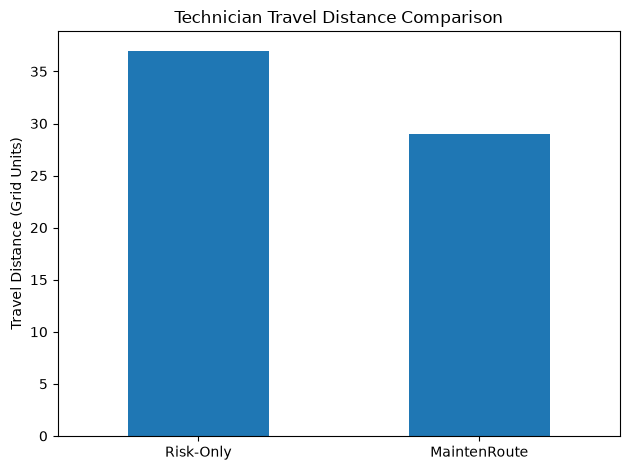

In [24]:
comparison.plot(
    x="Strategy",
    y="Travel Distance",
    kind="bar",
    legend=False,
    title="Technician Travel Distance Comparison"
)

plt.ylabel(
    "Travel Distance (Grid Units)"
)

plt.xlabel("")

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.show()

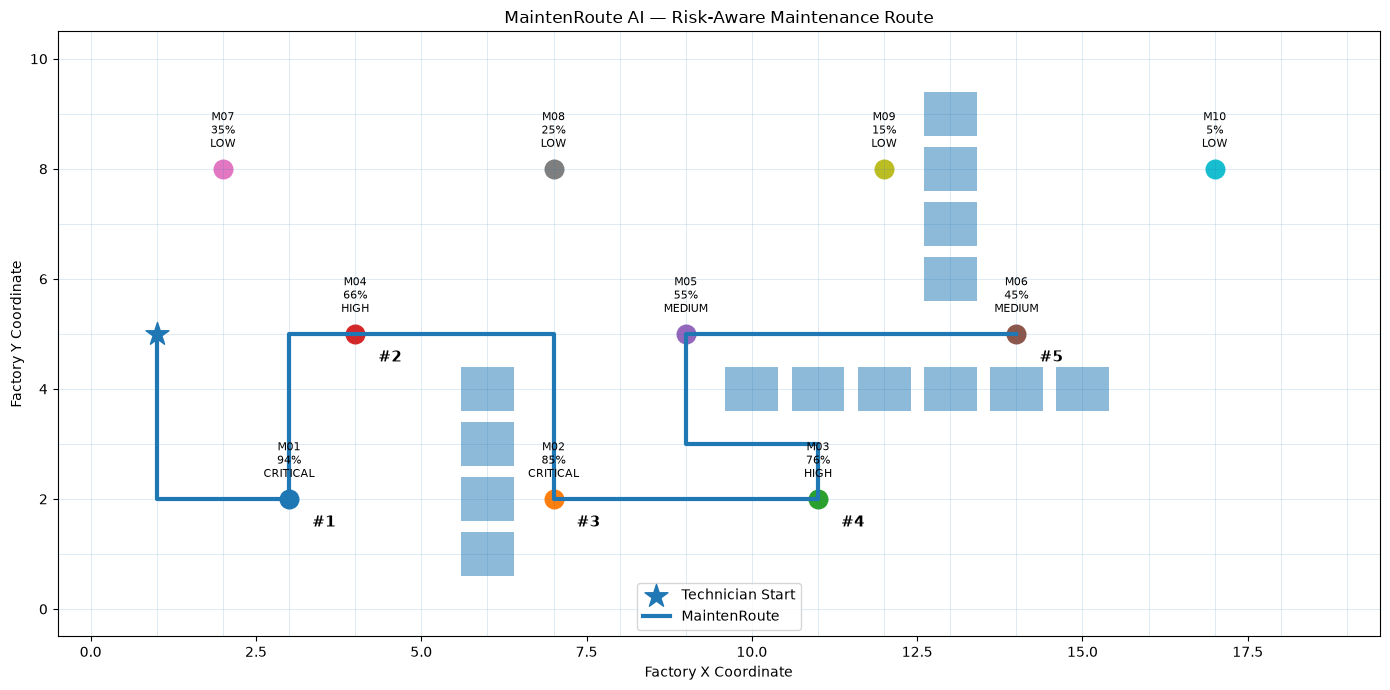

In [25]:
fig, ax = plt.subplots(
    figsize=(14, 7)
)


# Grid
for x in range(GRID_WIDTH):
    ax.axvline(
        x,
        linewidth=0.5,
        alpha=0.2
    )

for y in range(GRID_HEIGHT):
    ax.axhline(
        y,
        linewidth=0.5,
        alpha=0.2
    )


# Obstacles
for x, y in obstacles:

    obstacle_patch = Rectangle(
        (
            x - 0.4,
            y - 0.4
        ),
        0.8,
        0.8,
        alpha=0.5
    )

    ax.add_patch(
        obstacle_patch
    )


# Factory assets
for _, row in assets.iterrows():

    x, y = row["Position"]

    ax.scatter(
        x,
        y,
        s=180
    )

    ax.text(
        x,
        y + 0.40,
        (
            f"{row['Asset ID']}\n"
            f"{row['Failure Risk']:.0%}\n"
            f"{row['Risk Level']}"
        ),
        ha="center",
        fontsize=8
    )


# Technician start
tx, ty = TECHNICIAN_START

ax.scatter(
    tx,
    ty,
    s=300,
    marker="*",
    label="Technician Start"
)


# MaintenRoute path
route_x = [
    position[0]
    for position
    in maintenroute_full_route
]

route_y = [
    position[1]
    for position
    in maintenroute_full_route
]


ax.plot(
    route_x,
    route_y,
    linewidth=3,
    label="MaintenRoute"
)


# Visit order labels
for order, (_, row) in enumerate(
    maintenance_sequence.iterrows(),
    start=1
):

    x, y = row["Position"]

    ax.text(
        x + 0.35,
        y - 0.50,
        f"#{order}",
        fontsize=11,
        fontweight="bold"
    )


ax.set_title(
    "MaintenRoute AI — Risk-Aware Maintenance Route"
)

ax.set_xlabel(
    "Factory X Coordinate"
)

ax.set_ylabel(
    "Factory Y Coordinate"
)

ax.set_xlim(
    -0.5,
    GRID_WIDTH - 0.5
)

ax.set_ylim(
    -0.5,
    GRID_HEIGHT - 0.5
)

ax.legend()

plt.tight_layout()

plt.show()

In [26]:
print(
    "MAINTENROUTE AI"
)

print(
    "=" * 60
)

print(
    "\nRecommended inspection sequence:"
)


for i, row in (
    maintenance_sequence.iterrows()
):

    print(
        f"{i + 1}. "
        f"{row['Asset ID']} | "
        f"Failure Risk: "
        f"{row['Failure Risk']:.1%} | "
        f"Risk Level: "
        f"{row['Risk Level']} | "
        f"Priority: "
        f"{row['Priority Score']:.3f}"
    )


print("\nOperational Evaluation")
print("-" * 60)

print(
    f"MaintenRoute distance: "
    f"{maintenroute_distance} grid units"
)

print(
    f"Risk-only distance: "
    f"{risk_only_distance} grid units"
)

print(
    f"Travel reduction: "
    f"{travel_reduction:.1f}%"
)

print(
    f"High-risk coverage: "
    f"{high_risk_coverage:.1f}%"
)

print(
    f"MaintenRoute weighted cost: "
    f"{maintenroute_risk_cost:.3f}"
)

print(
    f"Risk-only weighted cost: "
    f"{risk_only_risk_cost:.3f}"
)

MAINTENROUTE AI

Recommended inspection sequence:
1. M01 | Failure Risk: 94.0% | Risk Level: CRITICAL | Priority: 0.873
2. M04 | Failure Risk: 65.7% | Risk Level: HIGH | Priority: 0.733
3. M02 | Failure Risk: 85.3% | Risk Level: CRITICAL | Priority: 0.821
4. M03 | Failure Risk: 76.0% | Risk Level: HIGH | Priority: 0.803
5. M06 | Failure Risk: 45.0% | Risk Level: MEDIUM | Priority: 0.597

Operational Evaluation
------------------------------------------------------------
MaintenRoute distance: 29 grid units
Risk-only distance: 37 grid units
Travel reduction: 21.6%
High-risk coverage: 100.0%
MaintenRoute weighted cost: 55.839
Risk-only weighted cost: 70.553


In [27]:
OUTPUT_DIR = Path(
    "../data/processed"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


maintenance_sequence.to_csv(
    OUTPUT_DIR
    / "maintenance_sequence.csv",
    index=False
)


comparison.to_csv(
    OUTPUT_DIR
    / "planning_comparison.csv",
    index=False
)


print(
    "Planning outputs saved successfully."
)

Planning outputs saved successfully.


In [28]:
weight_results = []

for weight in [
    0.20,
    0.40,
    0.60,
    0.80,
    1.00
]:

    test_sequence = (
        build_risk_aware_sequence(
            priority_assets,
            TECHNICIAN_START,
            distance_weight=weight
        )
    )

    _, test_segments = (
        build_full_route(
            TECHNICIAN_START,
            test_sequence
        )
    )

    test_distance = sum(
        segment["Distance"]
        for segment
        in test_segments
    )

    weight_results.append(
        {
            "Distance Weight":
                weight,

            "Travel Distance":
                test_distance,

            "Sequence":
                " → ".join(
                    test_sequence[
                        "Asset ID"
                    ]
                )
        }
    )


weight_evaluation = pd.DataFrame(
    weight_results
)

weight_evaluation

,Distance Weight,Travel Distance,Sequence
0,0.2,37,M01 → M02 → M03 → M04 → M06
1,0.4,37,M01 → M02 → M03 → M04 → M06
2,0.6,37,M01 → M02 → M03 → M04 → M06
3,0.8,29,M01 → M04 → M02 → M03 → M06
4,1.0,29,M01 → M04 → M02 → M03 → M06
